In [1]:
#import libraries
import torch
from torch import nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#import dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [3]:
# variables
num_classes = 10
batch_size = 64
num_channels = 1
img_size = 28
patch_size = 7
num_patches = (img_size // patch_size) ** 2
embedding_dimension = 64
attention_heads = 4
num_transformer_blocks = 8
mlp_dimension = 128
learning_rate = 0.001
num_epochs = 10

In [4]:
# dataloaders for batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [5]:
# Steps:
# 1. Patch Embedding
# 2. Transformer Encoder
# 3. MLP head
# 4. ViT class

In [7]:
# Patch embedding
# Only for single-channel images

class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc = nn.Linear(patch_size**2, embedding_dimension)
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dimension))
    self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dimension))

  def forward(self, x):
    B, C, H, W = x.shape
    x = x.unfold(3, patch_size, patch_size)
    x = x.unfold(2, patch_size, patch_size)
    x = x.permute(0,2,3,1,4,5)
    x = x.contiguous()
    x = x.flatten(1,2)
    x = x.flatten(2)
    x = x.contiguous()
    x = self.fc(x)

    cls = self.cls_token.expand(B, -1, -1)
    x = torch.cat([cls, x], dim=1)

    x = x + self.pos_embedding
    return x

In [8]:
# Transformer encoder

class TransformerBlock(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(embedding_dimension)
    self.layer_norm_2 = nn.LayerNorm(embedding_dimension)
    self.MHA = nn.MultiheadAttention(embedding_dimension, attention_heads, batch_first=True)
    self.MLP = nn.Sequential(nn.Linear(embedding_dimension, mlp_dimension), nn.GELU(), nn.Linear(mlp_dimension, embedding_dimension))

  def forward(self, x):
    x_res1 = x
    x = self.layer_norm_1(x)
    x, _ = self.MHA(x, x, x)
    x = x + x_res1
    x_res2 = x
    x = self.layer_norm_2(x)
    x = self.MLP(x)
    x = x + x_res2
    return x

In [9]:
# MLP head

class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc = nn.Linear(embedding_dimension, num_classes)
    self.layer_norm = nn.LayerNorm(embedding_dimension)

  def forward(self, x):
    x = self.layer_norm(x)
    cls = x[:, 0]
    x = self.fc(cls)
    return x

In [10]:
# ViT class

class ViT(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.transformer_blocks = nn.ModuleList([TransformerBlock() for _ in range(num_transformer_blocks)])
    self.mlp_head = MLP_head()

  def forward(self, x):
    x = self.patch_embedding(x)
    for transformer_block in self.transformer_blocks:
      x = transformer_block(x)
    x = self.mlp_head(x)
    return x

In [11]:
x = torch.randn(64, 1, 28, 28)

x = PatchEmbedding()(x)
print(x.shape)
x = TransformerBlock()(x)
print(x.shape)
x = MLP_head()(x)
print(x.shape)

print("********************")
x = torch.randn(64, 1, 28, 28)
model_ViT = ViT()
output = model_ViT(x)
print(output.shape)

torch.Size([64, 17, 64])
torch.Size([64, 17, 64])
torch.Size([64, 10])
********************
torch.Size([64, 10])


In [12]:
x = torch.randn(64, 3, 28, 28)

B, C, H, W = x.shape
x = x.unfold(3, patch_size, patch_size)
print(x.shape)
x = x.unfold(2, patch_size, patch_size)
print(x.shape)
x = x.permute(0,2,3,1,4,5)
print(x.shape)
x = x.flatten(1,2)
print(x.shape)
x = x.flatten(2)
print(x.shape)
# x = x.contiguous()
# x = self.fc(x)

torch.Size([64, 3, 28, 4, 7])
torch.Size([64, 3, 4, 4, 7, 7])
torch.Size([64, 4, 4, 3, 7, 7])
torch.Size([64, 16, 3, 7, 7])
torch.Size([64, 16, 147])


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model_ViT = ViT()
model_ViT.to(device)

criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model_ViT.parameters(), lr=learning_rate)

cuda


In [14]:
accumulated_losses_train = []
accumulated_losses_val = []

for i in range(num_epochs):
  accumulated_loss_train = 0
  accumulated_loss_val = 0

  print("Epoch: #", i+1)

  model_ViT.train()
  for images, results in train_loader:
    images = images.to(device)
    results = results.to(device)
    y = model_ViT(images)
    optimizer.zero_grad()
    loss = criterion(y, results)
    accumulated_loss_train += loss.item()
    loss.backward()
    optimizer.step()

  model_ViT.eval()
  with torch.no_grad():
    for images, results in val_loader:
      images = images.to(device)
      results = results.to(device)
      y = model_ViT(images)
      loss = criterion(y, results)
      accumulated_loss_val += loss.item()


  accumulated_loss_train /= len(train_loader)
  print("Train: ",accumulated_loss_train)
  accumulated_losses_train.append(accumulated_loss_train)

  accumulated_loss_val /= len(val_loader)
  print("Val/ Test: ", accumulated_loss_val)
  accumulated_losses_val.append(accumulated_loss_val)
  print("********************")

Epoch: # 1
Train:  0.3843466832693706
Val/ Test:  0.1468513023143836
********************
Epoch: # 2
Train:  0.11815358191005775
Val/ Test:  0.10443022979014097
********************
Epoch: # 3
Train:  0.08777835092662192
Val/ Test:  0.10013530324331847
********************
Epoch: # 4
Train:  0.07099488500837309
Val/ Test:  0.07808213326991031
********************
Epoch: # 5
Train:  0.06120603038509414
Val/ Test:  0.08331562511498333
********************
Epoch: # 6
Train:  0.053566503147634344
Val/ Test:  0.08199488461925203
********************
Epoch: # 7
Train:  0.045910287690823025
Val/ Test:  0.0652096693683564
********************
Epoch: # 8
Train:  0.04101886806843518
Val/ Test:  0.06377740197938832
********************
Epoch: # 9
Train:  0.03791824188178975
Val/ Test:  0.06620002831154426
********************
Epoch: # 10
Train:  0.03603271310256649
Val/ Test:  0.06397191137794678
********************


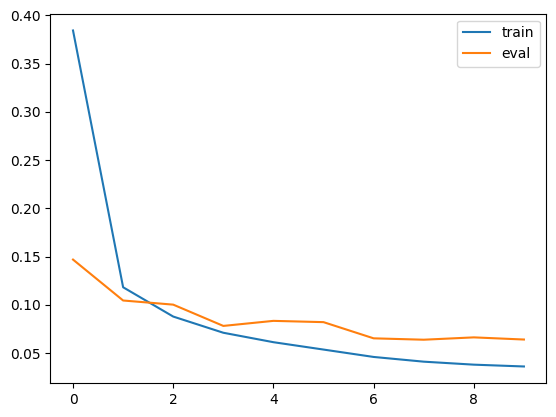

In [15]:
from matplotlib import legend
import matplotlib.pyplot as plt

plt.plot(accumulated_losses_train, label = "train")
plt.plot(accumulated_losses_val, label = "eval")
plt.legend()

In [16]:
images, results = next(iter(val_loader))
c = 0
while c < 5:
  i = np.random.randint(0, 64)
  images = images.to(device)
  results = results.to(device)
  output = model_ViT(images)
  pred = torch.argmax(output, dim=1)
  print(pred[i].to('cpu').numpy()== results[i].to('cpu').numpy())
  c += 1

True
True
True
True
True
